# Experimentos com MLP criado para o dataset MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from mlp.network import MLP

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784) / 255.0
X_test  = X_test.reshape(-1, 784) / 255.0

def one_hot(y, n_classes=10):
    out = np.zeros((len(y), n_classes))
    out[np.arange(len(y)), y] = 1
    return out

y_train_oh = one_hot(y_train)
y_test_oh  = one_hot(y_test)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (60000, 784)
X_test:  (10000, 784)


## Treinamento base (2 epocas e Lr = 0.01)

In [3]:
model = MLP(lr=0.01)
historico = model.treinar(X_train, y_train_oh, X_test, y_test, epocas=2)

epoca 1/2 — loss: 0.3787 — acurácia: 94.78%
epoca 2/2 — loss: 0.1176 — acurácia: 96.82%


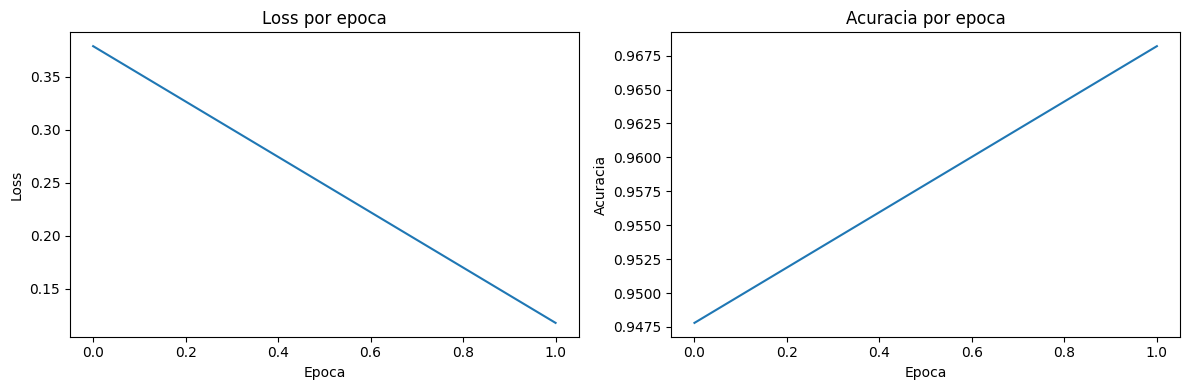

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historico['loss'])
ax1.set_title('Loss por epoca')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')

ax2.plot(historico['acuracia'])
ax2.set_title('Acuracia por epoca')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Acuracia')

plt.tight_layout()
plt.savefig('../results/curvas_treinamento.png', dpi=150)
plt.show()

In [5]:
correct = sum(model.predicao(X_test[i]) == y_test[i] for i in range(len(X_test)))
print(f'Acuracia com 2 epocas e lr = 0.01: {correct / len(X_test) * 100:.2f}%')

Acuracia com 2 epocas e lr = 0.01: 96.82%


## Treinamento 2 (2 epocas e Lr = 0.02)

In [6]:
model = MLP(lr=0.02)
historico = model.treinar(X_train, y_train_oh, X_test, y_test, epocas=2)

epoca 1/2 — loss: 0.3267 — acurácia: 95.54%
epoca 2/2 — loss: 0.1349 — acurácia: 96.47%


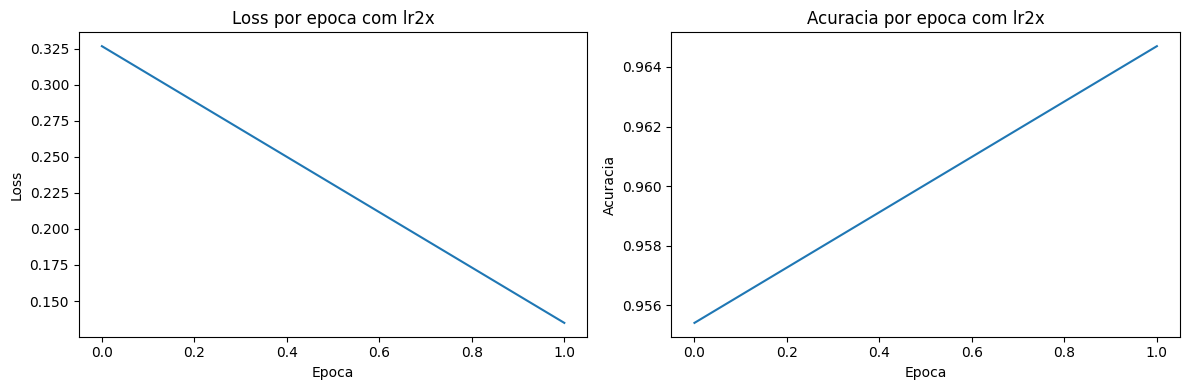

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historico['loss'])
ax1.set_title('Loss por epoca com lr2x')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')

ax2.plot(historico['acuracia'])
ax2.set_title('Acuracia por epoca com lr2x')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Acuracia')

plt.tight_layout()
plt.savefig('../results/curvas_treinamento_lr2x.png', dpi=150)
plt.show()

In [8]:
correct = sum(model.predicao(X_test[i]) == y_test[i] for i in range(len(X_test)))
print(f'Acuracia com 2 epocas e lr = 0.02: {correct / len(X_test) * 100:.2f}%')

Acuracia com 2 epocas e lr = 0.02: 96.47%


## Treinamento 3 (4 epocas e Lr = 0.01)

In [9]:
model = MLP(lr=0.01)
historico = model.treinar(X_train, y_train_oh, X_test, y_test, epocas=4)

epoca 1/4 — loss: 0.3873 — acurácia: 94.59%
epoca 2/4 — loss: 0.1169 — acurácia: 97.15%
epoca 3/4 — loss: 0.0824 — acurácia: 97.35%
epoca 4/4 — loss: 0.0657 — acurácia: 97.44%


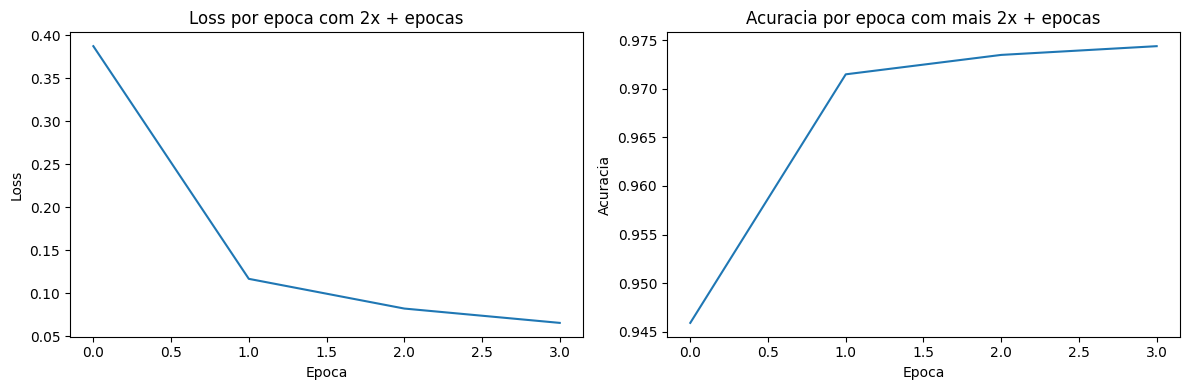

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historico['loss'])
ax1.set_title('Loss por epoca com 2x + epocas')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')

ax2.plot(historico['acuracia'])
ax2.set_title('Acuracia por epoca com mais 2x + epocas')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Acuracia')

plt.tight_layout()
plt.savefig('../results/curvas_treinamento_epoch2x.png', dpi=150)
plt.show()

In [11]:
correct = sum(model.predicao(X_test[i]) == y_test[i] for i in range(len(X_test)))
print(f'Acuracia com 4 epocas e lr = 0.01: {correct / len(X_test) * 100:.2f}%')

Acuracia com 4 epocas e lr = 0.01: 97.44%
